## Task 2: Least Squares, Closed Form vs Gradient Descent

In this homework you will fit a **linear regression** model on a real dataset and solve the **least squares** problem in two ways:

1. **Visualize** the dataset in 3D using **PCA** (given).
2. Understand the **least squares objective** and the **pseudoinverse** closed-form solution (given reference).
3. Implement **gradient descent** for least squares and verify it matches the pseudoinverse solution.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


## Subtask 1: Load a real dataset, reduce to 2D with PCA, and plot

### The dataset (real-life context)
We use the **Diabetes** dataset (442 patients). For each patient, we have **10 baseline variables** (measured at the start of the study):
- age, sex, BMI, blood pressure
- six blood serum measurements

The target $y$ is a quantitative measure of **disease progression one year later**.

### PCA for visualization
The feature vector lives in $\mathbb{R}^{10}$, which we cannot plot directly. PCA finds orthogonal directions (principal components) capturing maximum variance in the input features. We keep the **first 2** components to visualize the dataset in 3D (the z-axis corresponds to the target), to see if there is a linear relationship between the input points and the targets.

Run the cell below to:
- load the data,
- compute PCA to 2D,
- show explained variance ratios,
- plot a **3D plots** where the z-axis corresponds to the target variable (disease progression $y$).


Loaded Diabetes dataset with n=442 samples and d=10 features.
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Explained variance ratio of first 2 PCs: [0.40242108 0.14923197]
Total explained variance (2 PCs): 0.5516530427751477


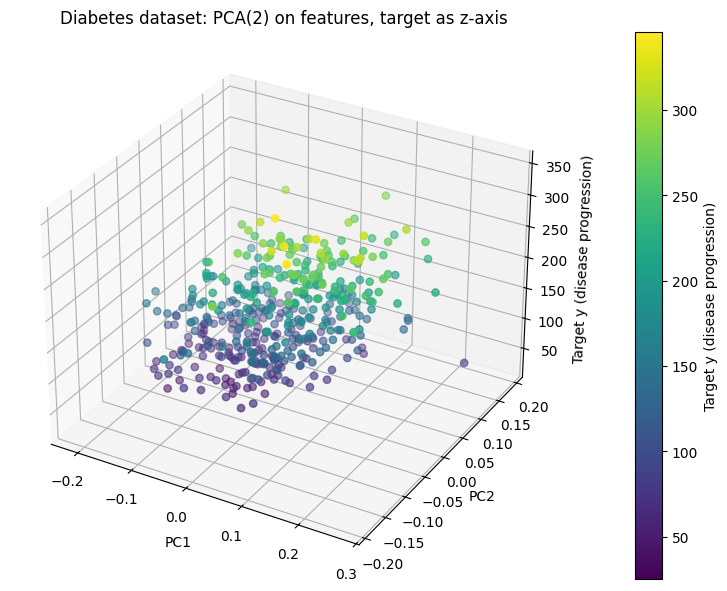

In [2]:
# --------------------------
# Task 1: Real dataset + PCA(2) + 3D plot with target as z (given)
# --------------------------

data = load_diabetes()
X = data.data            # (n, 10)
y = data.target          # (n,)
feature_names = data.feature_names

n, d = X.shape
print(f"Loaded Diabetes dataset with n={n} samples and d={d} features.")
print("Features:", feature_names)

# PCA to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X)

print("\nExplained variance ratio of first 2 PCs:", pca.explained_variance_ratio_)
print("Total explained variance (2 PCs):", float(pca.explained_variance_ratio_.sum()))

# 3D scatter: (PC1, PC2, target y)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(X2[:, 0], X2[:, 1], y, c=y, s=28)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("Target y (disease progression)")
ax.set_title("Diabetes dataset: PCA(2) on features, target as z-axis")

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Target y (disease progression)")

plt.tight_layout()
plt.show()


## Subtask 2: Least squares and the pseudoinverse

### Least squares objective (linear regression)
Given a design matrix $A \in \mathbb{R}^{n\times d}$ and targets $b \in \mathbb{R}^n$, the (linear) least squares problem is:

$$
\min_{\theta \in \mathbb{R}^{d}} \ \|A\theta - b\|_2^2.
$$

In linear regression we typically include an **intercept** term by appending a column of ones to the features:

$$
A = \begin{bmatrix}
x_1^\top & 1\\
x_2^\top & 1\\
\vdots & \vdots\\
x_n^\top & 1
\end{bmatrix}, \quad
\theta = \begin{bmatrix} w \\ c \end{bmatrix},
\quad
\hat b = A\theta.
$$

### Closed-form minimizer (pseudoinverse)
A key fact we saw in class is that the minimizer can be written using the **Moore–Penrose pseudoinverse** $A^+$:

$$
\theta^\star = A^+ b.
$$

When $A$ has **full column rank**, the pseudoinverse can be expressed as:

$$
A^+ = (A^\top A)^{-1}A^\top
\quad \Rightarrow \quad
\theta^\star = (A^\top A)^{-1}A^\top b.
$$

In practice, `np.linalg.pinv(A)` computes $A^+$ using an SVD (numerically stable).

In the following task, use the above formulas to implement the computation of the pseudoinverse. The rest of the code is given, and computes the least-squares closed-form solution vector.


In [ ]:

def add_intercept(Xm: np.ndarray) -> np.ndarray:
    """Append a column of ones for an intercept term."""
    return np.column_stack([Xm, np.ones(Xm.shape[0])])


def pseudoinverse_normal_eq(A: np.ndarray) -> np.ndarray:
    """

    When A has full column rank:
        A^+ = (A^T A)^{-1} A^T

    Parameters
    ----------
    A : np.ndarray, shape (n, d)

    Returns
    -------
    A_pinv : np.ndarray, shape (d, n)
        The pseudoinverse of A.
    """
    A_pinv = np.linalg.pinv(A)
    return A_pinv


def solve_least_squares_pinv(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    Solve least squares using your pseudoinverse implementation.

    theta* = A^+ b

    Parameters
    ----------
    A : np.ndarray, shape (n, d)
    b : np.ndarray, shape (n,) or (n, 1)

    Returns
    -------
    theta_star : np.ndarray, shape (d,)
    """
    b = np.asarray(b).reshape(-1)

    A_pinv = pseudoinverse_normal_eq(A)

    theta_star = A_pinv @ b
    return theta_star


## Subtask 3: Solve least squares with gradient descent

We will minimize the **scaled** least squares objective:

$$
J(\theta) = \frac{1}{2n}\|A\theta - b\|_2^2.
$$

### (a) Gradient
We saw in class that the gradient is:

$$
\nabla J(\theta) = \frac{1}{n} A^\top(A\theta - b).
$$

You will implement this gradient in `least_squares_grad(...)`.

### (b) Learning rate choice
For a quadratic objective, gradient descent converges for step sizes below a threshold related to the curvature.
For $J(\theta)$ above, a sufficient condition is:

$$
0 < \eta < \frac{2}{L}, \qquad L = \frac{1}{n}\|A\|_2^2,
$$

where $\|A\|_2\$ is the **spectral norm** (largest singular value).

You will set a learning rate using this idea (a conservative choice is $\eta = 1/L$).

### (c) Gradient descent loop
Uncomment the appropriate lines to implement gradient descent, which returns an approximate minimizer $\theta_{\text{gd}}$.

You will then run a **test cell** that checks $\theta_{\text{gd}}$ matches the pseudoinverse solution up to a small tolerance.


In [ ]:

def least_squares_grad(A: np.ndarray, b: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """
    Gradient of J(theta) = (1/(2n)) ||A theta - b||_2^2.

    Parameters
    ----------
    A : (n, d') design matrix
    b : (n,) target vector
    theta : (d',) parameter vector

    Returns
    -------
    grad : (d',) gradient vector
    """
    n = A.shape[0]
    grad = (1 / len(A)) * A.T @ (A @ theta - b)
    return grad


def choose_learning_rate(A: np.ndarray) -> float:
    """
    Choose a learning rate using a Lipschitz constant bound.

    For J(theta) = (1/(2n))||A theta - b||^2, one can use:
        L = (1/n) * ||A||_2^2
    A conservative stable choice is eta = 1/L.

    Returns
    -------
    eta : float
    """
    n = A.shape[0]
    sigma_max = np.linalg.svd(A, compute_uv=False)[0]
    L = (1/n) * sigma_max**2
    eta = 1/L
    return eta


def solve_least_squares_gd(
    A: np.ndarray,
    b: np.ndarray,
    n_steps: int = 5000,
    tol: float = 1e-8,
) -> np.ndarray:
    """
    Solve least squares with gradient descent on J(theta)=(1/(2n))||A theta - b||^2.

    Parameters
    ----------
    A : (n, d') design matrix
    b : (n,) target vector
    n_steps : number of GD iterations
    tol : stopping tolerance on gradient norm

    Returns
    -------
    theta_gd : (d',) approximate minimizer
    """
    b = np.asarray(b).reshape(-1)
    dprime = A.shape[1]
    theta = np.zeros(dprime)

    eta = choose_learning_rate(A)

    for t in range(n_steps):
        g = least_squares_grad(A, b, theta)

        theta = theta - eta * g

        if np.linalg.norm(g) < tol:
            break

    return theta


14.226707390822694
14.2828568570857


## Testing cell (given): Compare GD to pseudoinverse

After you finish Task 3, run the cell below.

It will:
1. Create a train split.
2. Fit least squares with **pseudoinverse** (reference).
3. Fit least squares with your **gradient descent** implementation.
4. Assert that the solutions match up to a small tolerance.


In [ ]:
def rel_error(a, b):
    return np.linalg.norm(a - b) / max(1e-12, np.linalg.norm(b))

# Train/test split (we test on TRAIN solution equivalence)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

A_train = add_intercept(X_train)  # use ALL original features + intercept
b_train = y_train

theta_pinv = solve_least_squares_pinv(A_train, b_train)
theta_gd   = solve_least_squares_gd(A_train, b_train, n_steps=400000, tol=1e-8)

print("theta_pinv:", theta_pinv)
print("theta_gd  :", theta_gd)
print("||theta_gd - theta_pinv||:", np.linalg.norm(theta_gd - theta_pinv))
print("relative error:", rel_error(theta_gd, theta_pinv))

# Test (tolerance can be tuned if needed)
tol = 1e-3
assert rel_error(theta_gd, theta_pinv) < tol, "GD solution is not close enough to pseudoinverse solution."

print("\n✅ Test passed: GD solution matches pseudoinverse within tolerance.")


theta_pinv: [ -43.26198867 -208.66589855  593.40654802  302.89100542 -560.19094014
  261.40753499   -8.86674758  135.93174293  703.18354112   28.34977176
  153.06786206]
theta_gd  : [ -43.26109641 -208.66509829  593.4084603   302.88957058 -560.07972365
  261.32072718   -8.91847308  135.91400493  703.14221714   28.35019785
  153.0678466 ]
||theta_gd - theta_pinv||: 0.15687534198977435
relative error: 0.0001321742020390361

✅ Test passed: GD solution matches pseudoinverse within tolerance.


## (Optional) Evaluate on the test set (given)

Once the test passes, you can also check prediction performance.


In [ ]:

A_test = add_intercept(X_test)

yhat_test_pinv = A_test @ theta_pinv
yhat_test_gd   = A_test @ theta_gd

mse = lambda yt, yp: float(np.mean((yt - yp) ** 2))

print("Test MSE (pinv):", mse(y_test, yhat_test_pinv))
print("Test MSE (gd)  :", mse(y_test, yhat_test_gd))


Test MSE (pinv): 3180.159648155842
Test MSE (gd)  : 3180.1681201434612


## Visualizing the fitted model in PCA space

In this cell we overlay the **least-squares model fit with gradient descent** on top of the PCA visualization.

- We use the **same 2D PCA coordinates** $(\mathrm{PC1}, \mathrm{PC2})$ as the x–y axes.
- The **z-axis is the target** $y$ (disease progression).
- The fitted weights define a **plane** in $(\mathrm{PC1}, \mathrm{PC2}, y)$-space.

This plot is meant to give intuition for what “least squares” is doing geometrically: it finds the plane that (in a squared-error sense) best approximates the vertical heights $y$ over the PCA plane.



GD plane parameters on PCA(2): [ 448.19478633 -256.74894226  152.13348416]


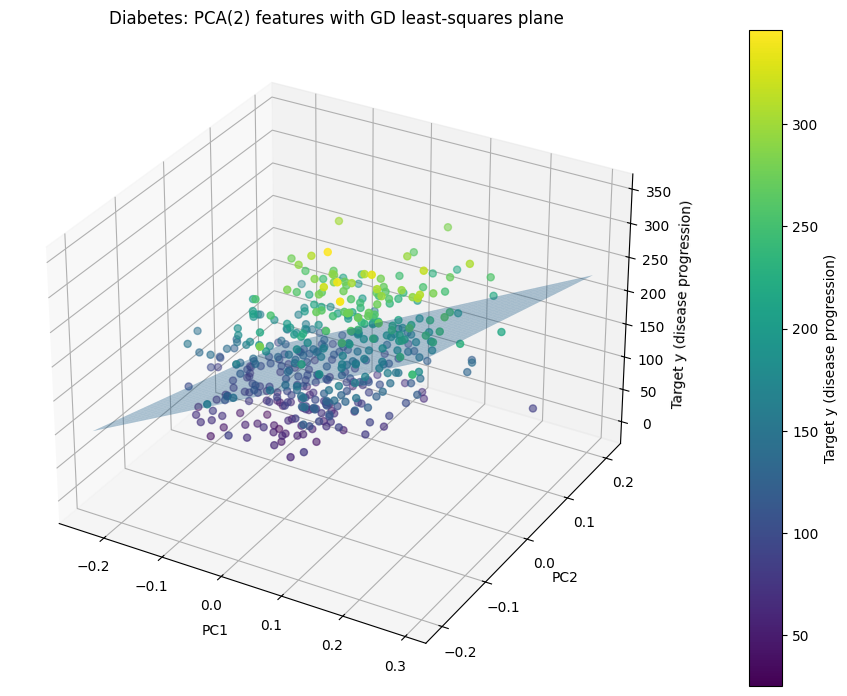

In [11]:
# --------------------------
# Given: PCA(2) 3D plot + GD fitted hyperplane in the same figure
# --------------------------
# Assumes you have already run the PCA(2) cell (so X2 and y exist),
# and that add_intercept(...) + solve_least_squares_gd(...) are defined.

# Fit a plane y_hat = theta0*PC1 + theta1*PC2 + theta2 using GD (on ALL points, for visualization)
A2 = add_intercept(X2)          # shape (n, 3) = [PC1, PC2, 1]
theta_gd_pca2 = solve_least_squares_gd(A2, y, n_steps=8000, tol=1e-10)

print("GD plane parameters on PCA(2):", theta_gd_pca2)

# Build a grid in (PC1, PC2) space and evaluate the plane
pc1_min, pc1_max = X2[:, 0].min(), X2[:, 0].max()
pc2_min, pc2_max = X2[:, 1].min(), X2[:, 1].max()
pad1 = 0.05 * (pc1_max - pc1_min)
pad2 = 0.05 * (pc2_max - pc2_min)

u = np.linspace(pc1_min - pad1, pc1_max + pad1, 30)
v = np.linspace(pc2_min - pad2, pc2_max + pad2, 30)
U, V = np.meshgrid(u, v)

Z_plane = theta_gd_pca2[0] * U + theta_gd_pca2[1] * V + theta_gd_pca2[2]

# Plot: points + fitted plane
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(X2[:, 0], X2[:, 1], y, c=y, s=26, label="data")
ax.plot_surface(U, V, Z_plane, alpha=0.35, rstride=1, cstride=1)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("Target y (disease progression)")
ax.set_title("Diabetes: PCA(2) features with GD least-squares plane")

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Target y (disease progression)")

plt.tight_layout()
plt.show()
